### Logistic Regression on Imbalanced Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import make_classification
from collections import Counter  # Library to create a counter object

In [6]:
X,y=make_classification(n_samples=100000,n_features=20,n_clusters_per_class=1,weights=[0.98765],flip_y=0,random_state=42)

In [7]:
Counter(y)

Counter({np.int64(0): 98766, np.int64(1): 1234})

In [8]:
import seaborn as sns

<Axes: >

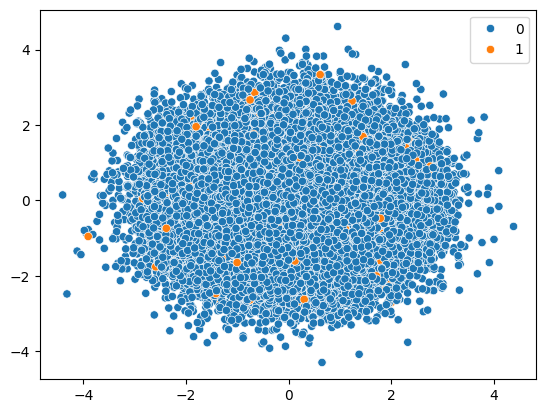

In [9]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_val=[0.01,0.1,1,10,100]
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [0.1,0.5,1,2,5] for y in [0.9,0.5,1,2,5]]

In [16]:
model.fit(X_train,y_train)

LogisticRegression()

In [17]:
y_pred=model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.99644
[[24671     0]
 [   89   240]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24671
           1       1.00      0.73      0.84       329

    accuracy                           1.00     25000
   macro avg       1.00      0.86      0.92     25000
weighted avg       1.00      1.00      1.00     25000

